First Best

Naïve Bayes: Accuracy=0.821, Precision=0.868, Recall=0.767, F1-score=0.808
c-SVM: Accuracy=0.842, Precision=0.868, Recall=0.808, F1-score=0.831
nu-SVM: Accuracy=0.854, Precision=0.869, Recall=0.842, F1-score=0.850
MLP: Accuracy=0.771, Precision=0.815, Recall=0.733, F1-score=0.758
KNN: Accuracy=0.825, Precision=0.841, Recall=0.808, F1-score=0.819
Random Forest: Accuracy=0.825, Precision=0.831, Recall=0.783, F1-score=0.800

Résultats avec Wrapper-based PSO (base KNN):


,Accuracy,Precision,Recall,F1-score
Naïve Bayes,0.820833,0.868434,0.766667,0.808197
c-SVM,0.841667,0.867897,0.808333,0.831414
nu-SVM,0.854167,0.868549,0.841667,0.850454
MLP,0.770833,0.815465,0.733333,0.758443
KNN,0.825000,0.840657,0.808333,0.819152
Random Forest,0.825000,0.830507,0.783333,0.800022


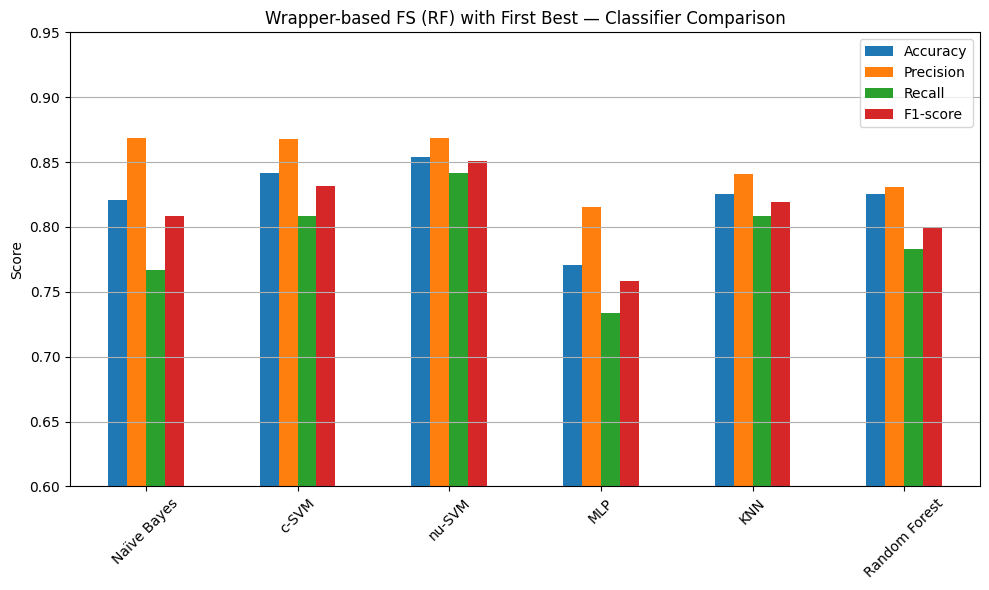

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Chargement des données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, drop_first=True)

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Définir les classifieurs
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "c-SVM": SVC(kernel="rbf", C=1.0),
    "nu-SVM": NuSVC(nu=0.5, kernel="rbf"),
    "MLP": MLPClassifier(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier()
}

# 4. Sélection de caractéristiques avec RF comme estimateur de base
base_selector = RandomForestClassifier()
sfs = SequentialFeatureSelector(base_selector, n_features_to_select='auto', direction='forward', cv=5, n_jobs=-1)
X_selected = sfs.fit_transform(X_scaled, y)

# 5. Évaluation par validation croisée 10-fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = {}

for name, clf in classifiers.items():
    acc = cross_val_score(clf, X_selected, y, cv=cv, scoring='accuracy').mean()
    pre = cross_val_score(clf, X_selected, y, cv=cv, scoring='precision').mean()
    rec = cross_val_score(clf, X_selected, y, cv=cv, scoring='recall').mean()
    f1 = cross_val_score(clf, X_selected, y, cv=cv, scoring='f1').mean()
    results[name] = [acc, pre, rec, f1]
    print(f"{name}: Accuracy={acc:.3f}, Precision={pre:.3f}, Recall={rec:.3f}, F1-score={f1:.3f}")

# 6. Affichage des résultats
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
df_results = pd.DataFrame(results, index=metrics).T
print("\nRésultats avec Wrapper-based PSO (base KNN):")
display(df_results)

# 7. Tracé des résultats
df_results.plot(kind='bar', figsize=(10,6))
plt.title("Wrapper-based FS (RF) with First Best — Classifier Comparison")
plt.ylabel("Score")
plt.ylim(0.6, 0.95)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Greed StepWise


Résultats avec Wrapper-based PSO (base KNN):


,Accuracy,Precision,Recall,F1-score
Naïve Bayes,0.833333,0.862002,0.808333,0.829070
c-SVM,0.829167,0.855120,0.800000,0.821310
nu-SVM,0.829167,0.855120,0.800000,0.821310
MLP,0.779167,0.826628,0.750000,0.777502
KNN,0.833333,0.846929,0.825000,0.831467
Random Forest,0.791667,0.841061,0.758333,0.780881


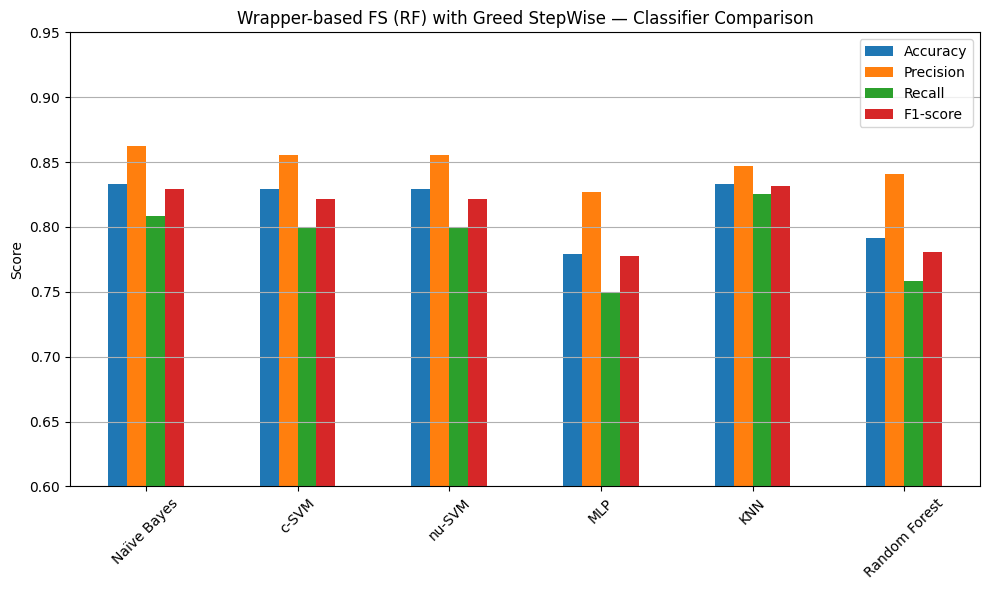

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Chargement des données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, drop_first=True)

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Définir les classifieurs
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "c-SVM": SVC(kernel="rbf", C=1.0),
    "nu-SVM": NuSVC(nu=0.5, kernel="rbf"),
    "MLP": MLPClassifier(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier()
}

# 4. Sélection de caractéristiques avec RF comme estimateur de base
base_selector = RandomForestClassifier()
sfs = SequentialFeatureSelector(base_selector, n_features_to_select='auto', direction='backward', cv=5, n_jobs=-1)
X_selected = sfs.fit_transform(X_scaled, y)

# 5. Évaluation par validation croisée 10-fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = {}

for name, clf in classifiers.items():
    acc = cross_val_score(clf, X_selected, y, cv=cv, scoring='accuracy').mean()
    pre = cross_val_score(clf, X_selected, y, cv=cv, scoring='precision').mean()
    rec = cross_val_score(clf, X_selected, y, cv=cv, scoring='recall').mean()
    f1 = cross_val_score(clf, X_selected, y, cv=cv, scoring='f1').mean()
    results[name] = [acc, pre, rec, f1]

# 6. Affichage des résultats
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
df_results = pd.DataFrame(results, index=metrics).T
print("\nRésultats avec Wrapper-based PSO (base KNN):")
display(df_results)

# 7. Tracé des résultats
df_results.plot(kind='bar', figsize=(10,6))
plt.title("Wrapper-based FS (RF) with Greed StepWise — Classifier Comparison")
plt.ylabel("Score")
plt.ylim(0.6, 0.95)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


PSO

2025-06-20 15:52:31,812 - pyswarms.discrete.binary - INFO - Optimize for 30 iters with {'c1': 2, 'c2': 2, 'w': 0.9, 'k': 5, 'p': 2}
pyswarms.discrete.binary:   0%|          |0/30

pyswarms.discrete.binary: 100%|██████████|30/30, best_cost=0.158
2025-06-20 16:02:48,311 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.15833333333333321, best pos: [1 0 1 0 0 1 1 0 0 0 1 1 0 1 0 0 1 1 1 1 1 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0
 1 0 0 1 0 0 1 1]



Résultats avec Wrapper-based PSO (base KNN):


,Accuracy,Precision,Recall,F1-score
Naïve Bayes,0.829167,0.856317,0.816667,0.829311
c-SVM,0.833333,0.848411,0.825000,0.831926
nu-SVM,0.829167,0.848370,0.816667,0.826927
MLP,0.820833,0.807732,0.808333,0.802576
KNN,0.825000,0.829534,0.825000,0.824639
Random Forest,0.829167,0.880871,0.800000,0.840661


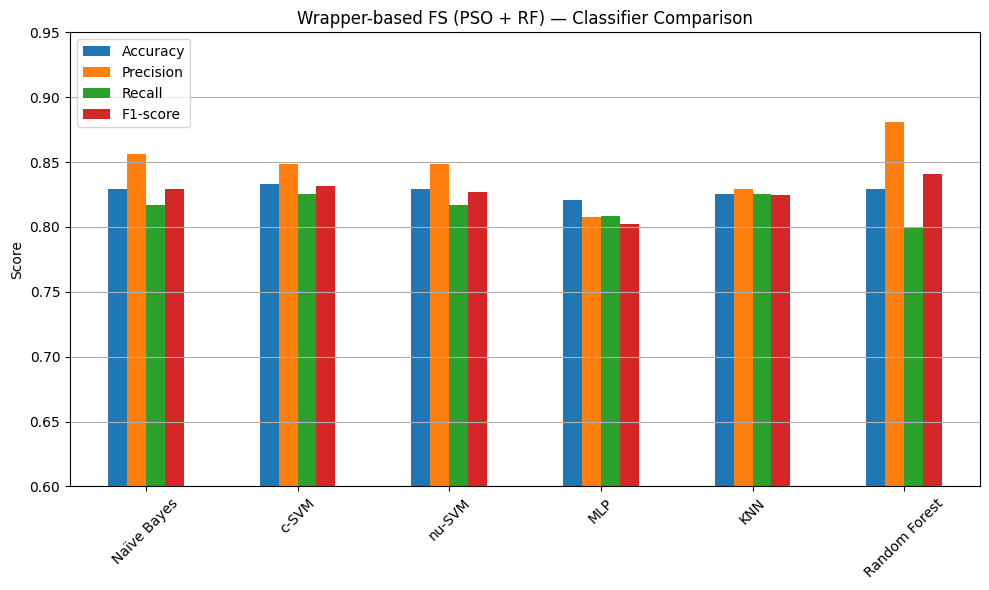

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import pyswarms as ps

# 1. Charger et préparer les données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
n_features = X_scaled.shape[1]

# 2. Fonction objectif (RF comme base classifier)
def objective_function(particles):
    scores = []
    for particle in particles:
        mask = particle.astype(bool)
        if np.sum(mask) == 0:
            scores.append(1.0)  # pénalité maximale
            continue
        X_subset = X_scaled[:, mask]
        clf = RandomForestClassifier()
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(clf, X_subset, y, cv=cv, scoring='accuracy').mean()
        scores.append(1 - score)  # minimiser 1 - accuracy
    return np.array(scores)

# 3. PSO - Feature Selection
options = {'c1': 2, 'c2': 2, 'w': 0.9, 'k': 5, 'p': 2}
optimizer = ps.discrete.BinaryPSO(n_particles=20, dimensions=n_features, options=options)
cost, best_position = optimizer.optimize(objective_function, iters=30, verbose=True)

# 4. Sélection finale des caractéristiques
selected_features = best_position.astype(bool)
X_selected = X_scaled[:, selected_features]

# 5. Évaluation des classifieurs avec validation croisée
classifiers = {
    "Naïve Bayes": GaussianNB(),
    "c-SVM": SVC(kernel="rbf"),
    "nu-SVM": NuSVC(nu=0.5, kernel="rbf"),
    "MLP": MLPClassifier(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier()
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = {}

for name, clf in classifiers.items():
    acc = cross_val_score(clf, X_selected, y, cv=cv, scoring='accuracy').mean()
    pre = cross_val_score(clf, X_selected, y, cv=cv, scoring='precision').mean()
    rec = cross_val_score(clf, X_selected, y, cv=cv, scoring='recall').mean()
    f1 = cross_val_score(clf, X_selected, y, cv=cv, scoring='f1').mean()
    results[name] = [acc, pre, rec, f1]

# 6. Visualisation
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
df_results = pd.DataFrame(results, index=metrics).T
print("\nRésultats avec Wrapper-based PSO (base KNN):")
display(df_results)

df_results.plot(kind='bar', figsize=(10,6))
plt.title("Wrapper-based FS (PSO + RF) — Classifier Comparison")
plt.ylabel("Score")
plt.ylim(0.6, 0.95)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
